In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
from astropy.table import Table
import matplotlib.gridspec as gridspec
import glob
import os
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import chisquare

colors = ['black', "r", 'navy',
    'forestgreen', 'c']

plt.style.use({
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.prop_cycle": cycler(
        color=colors)
})

def add_twins(ax=None):
    if ax is None:
        ax = plt.gca()

    ax.minorticks_on()

    ax_top = ax.twiny()
    ax_right = ax.twinx()

    ax_top.set_xticklabels([])
    ax_right.set_yticklabels([])

    ax_top.minorticks_on()
    ax_right.minorticks_on()

    def sync_x(event_ax):
        ax_top.set_xlim(event_ax.get_xlim())

    def sync_y(event_ax):
        ax_right.set_ylim(event_ax.get_ylim())

    ax.callbacks.connect('xlim_changed', sync_x)
    ax.callbacks.connect('ylim_changed', sync_y)

    sync_x(ax)
    sync_y(ax)

    return ax, ax_top, ax_right

def mask_lines(wave, lines, width=10):
    """
    """
    
    wave = np.asarray(wave)
    lines = np.asarray(lines)

    diff = np.abs(wave[:, None] - lines[None, :])

    mask = np.all(diff > width, axis=1)

    return mask

def mk_three_fig(hspace=0.3, wspace=0.5, spec_plot=True,
    figsize=(10, 8)):
    """
    """

    fig = plt.figure(figsize=figsize)

    gs = gridspec.GridSpec(2, 2, hspace=hspace)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])
    
    ax3.set_in_layout(False)

    pos1 = ax1.get_position()
    pos3 = ax3.get_position()

    new_width = pos1.width
    new_x = 0.5 - new_width / 2

    ax3.set_position([new_x, pos3.y0, new_width, pos3.height])
    
    if spec_plot:
        for ax in [ax1, ax2, ax3]:
            ax.set_ylabel('Flux [$10^{-14} \\ \\mathrm{erg \\ s^{-1} \\ cm^{-2} \\ \\AA}$]')
            ax.set_xlabel('Wavelength [$\\mathrm{\\AA}$]')

    return fig, ax1, ax2, ax3

def get_spectra_fits(fits_file):
    """
    """
    
    hdul = fits.open(fits_file)
    data = Table(hdul[1].data)
    
    lam = np.array(data['WAVELENGTH'])
    flux = np.array(data['FLUX'])
    
    hdul.close()
    
    spec = {'wl':lam, 'flux':flux}
    
    return spec

def read_spec(spec_file):
    """
    """
    
    data = np.loadtxt(spec_file, comments='#')
    
    lam = np.array(data[:,0])
    flux = np.array(data[:,1])
    
    return lam, flux

def parse_filename(fname):
    """
    """
    
    base = os.path.basename(fname).replace(".spec", "")
    parts = base.split("_")

    age_part = parts[1]
    z_part   = parts[2]

    Z = float(z_part.replace("z", "."))

    if "Gyr" in age_part:
        age_Gyr = float(age_part.replace("Gyr", ""))
    elif "Myr" in age_part:
        age_Gyr = float(age_part.replace("Myr", "")) / 1000.0
    else:
        raise ValueError(f"Unknown age unit in {fname}")

    return Z, age_Gyr

def get_ssps(temp_path):

    files = glob.glob(os.path.join(temp_path, "ssp*.spec"))

    files_sorted = sorted(files, key=lambda f: parse_filename(f))

    data_dict = {}

    for f in files_sorted:
        Z, age = parse_filename(f)
        data_dict[(Z, age)] = read_spec(f)

    return data_dict

def rebin_scale_mask(ssp_lam, ssp_flux, temp_lam, temp_flux, mask=None, norm=None):
    """
    """
    
    if mask is not None:
        temp_lam = temp_lam[mask]
        temp_flux = temp_flux[mask]
    
    model_lam = np.interp(temp_lam, ssp_lam, ssp_lam)
    model_flux = np.interp(temp_lam, ssp_lam, ssp_flux)
    
    scale = np.sum(temp_flux * model_flux) / np.sum(model_flux**2)
    model_flux_scale = model_flux * scale
    
    if norm:
        chisq = np.sum(((model_flux_scale / norm) - (temp_flux / norm))**2)
    else:
        chisq = np.sum((model_flux_scale - temp_flux)**2)
    
    red_chisq = chisq / (len(temp_flux))
    
    res_dict = {'wl': model_lam, 'flux': model_flux_scale,
        'chisq': red_chisq, 'red_chisq': red_chisq}
    
    return res_dict

def plot_spectra(lam, flux, fig=None, ax=None, title=None,
    label=None, color=None, lw=0.75, zorder=None,
    spec_plot=True, alpha=1, f_norm=1, wl_norm=1):
    """
    """

    if fig is None and ax is None:
        fig, ax = plt.subplots()

    ax.plot(lam / wl_norm, flux / f_norm,
        lw=lw, label=label, color=color,
        zorder=zorder, alpha=alpha)

    ax.minorticks_on()

    if title is not None:
        ax.set_title(title)

    if spec_plot:
        if wl_norm == 1:
            wl_label = r'Wavelength [$\mathrm{\AA}$]'
        else:
            wl_exp = int(np.log10(wl_norm))
            wl_label = rf'Wavelength [$10^{{{wl_exp}}} \ \mathrm{{\AA}}$]'
            
        if f_norm == 1:
            flux_label = (
                r'Flux [$\mathrm{erg \ s^{-1} \ cm^{-2} \ \AA^{-1}}$]')
        else:
            f_exp = int(np.log10(f_norm))
            flux_label = (
                rf'Flux [$10^{{{f_exp}}} \ '
                r'\mathrm{erg \ s^{-1} \ cm^{-2} \ \AA^{-1}}$]')

        ax.set_xlabel(wl_label)
        ax.set_ylabel(flux_label)

    return fig, ax

def find_best_model(ssps, temp_lam, temp_flux, key_filter=None,
    mask=None, norm=None, top_n=4, fit_range=None):
    """
    """
    
    fit_mask = np.ones_like(temp_lam, dtype=bool)
    
    if mask is not None:
        fit_mask &= mask
        
    if fit_range is not None:
        lam_min, lam_max = fit_range
        fit_mask &= ((temp_lam >= lam_min) &
            (temp_lam <= lam_max))

    if key_filter is None:
        filtered_items = ssps.items()
    else:
        filtered_items = ((k, v) for k, v in ssps.items()
            if key_filter(k))

    results = {k: rebin_scale_mask(*v, temp_lam, temp_flux,
        mask=mask, norm=norm)
        for k, v in filtered_items}

    sorted_results = sorted(
        results.items(),
        key=lambda item: item[1]['red_chisq'])

    top_dict = dict(sorted_results[:top_n])

    return top_dict, dict(sorted_results)

def plot_results(data_dict, temp_wl, temp_flux,
    wl_norm=1e3, flux_norm=1e-13,
    xlabel=r'Wavelength [$10^3 \mathrm{\AA}$]',
    ylabel=r'Flux [$10^{-13} \ \mathrm{erg \ s^{-1} \ cm^{-2} \ \AA}$]',
    title=None, shift=None,
    spec_kwargs=None, resid_kwargs=None,
    legend=False, temp_colors=None,
    legend_kwargs=None, fig=None, ax=None,
    suptitle=False, twins=True, text=True,
    text_loc=(0.025, 0.9),
    text_y_space=0.1, text_x_space=0.185,
    orient='vertical', ylim=None, xlim=None):
    """
    """

    colors = ['black', "r", 'navy',
        'forestgreen', 'c']

    if spec_kwargs is None:
        spec_kwargs = {}
    if resid_kwargs is None:
        resid_kwargs = {'s': 1}
    if legend_kwargs is None:
        legend_kwargs = {'loc': "best",
                         'fontsize': 9, 'ncol': 2}

    if fig is None and ax is None:
        fig, ax = plt.subplots(figsize=(7, 5.2),
            constrained_layout=True)

    obs_lam_full  = temp_wl
    obs_flux_full = temp_flux

    obs_lam_plot  = obs_lam_full / wl_norm
    obs_flux_plot = obs_flux_full / flux_norm

    if shift is None:
        shift = 1.1 * np.nanmax(obs_flux_plot)

    if isinstance(shift, int):
        add = f' + {shift} '
    else:
        add = f' + {shift:.2f} '
    ylabel = ylabel[:4] + add + ylabel[4:]

    plot_spectra(obs_lam_full, obs_flux_full + shift * flux_norm,
        ax=ax, lw=1.5, zorder=3, label="Observed",
        wl_norm=wl_norm, f_norm=flux_norm,
        spec_plot=False, **spec_kwargs)
    
    if orient == 'horizontal':
        obs_text_pos = (text_loc[0], text_loc[1]+0.025)
    else:
        obs_text_pos = text_loc
    
    if text:
        ax.text(*obs_text_pos, "Observed",
            transform=ax.transAxes,
            weight='semibold')

    if not temp_colors:
        temp_colors = colors[2:]
        
    running_x = text_loc[0]
    running_y = text_loc[1]

    for i, ((key, val), color) in enumerate(
            zip(data_dict.items(), [colors[1]] + temp_colors)):

        model_lam_fit = val['wl']
        model_flux_fit = val['flux']
        model_chi2 = val['red_chisq']

        model_flux_full = np.interp(obs_lam_full,
            model_lam_fit, model_flux_fit)
        
        label = f"{key}\n"
        label += rf"$\boldsymbol{{\mathrm{{MSE}}={model_chi2:.5f}}}$"

        plot_spectra(obs_lam_full,
            model_flux_full + shift * flux_norm,
            ax=ax, zorder=2 - i, color=color,
            label=label,
            wl_norm=wl_norm, f_norm=flux_norm,
            spec_plot=False, **spec_kwargs)

        residual = (obs_flux_full - model_flux_full) / flux_norm

        ax.scatter(obs_lam_plot, residual,
            color=color, **resid_kwargs, zorder=2-i,
            alpha=0.6)
        
        if orient == 'vertical':
            running_y -= text_y_space
        elif orient == 'horizontal':
            running_x += text_x_space
        
        text_pos = (running_x, running_y)
        
        if text:
            ax.text(*text_pos, label,
                transform=ax.transAxes,
                weight='semibold',
                color=color)

    ax.axhline(0, color="gray", alpha=0.7, zorder=0)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    if twins:
        add_twins(ax = ax)

    if legend:
        ax.legend(
            frameon=False,
            fontsize=7,
            ncol=2,
            handlelength=1.5,
            columnspacing=1.2)

    best_key = next(iter(data_dict.keys()))
    title_str = title if title else ""
    title_str += (f"Best Fit — Z: {best_key[0]}; "
        f"Age: {best_key[1]} Gyr")

    if len(best_key) > 2:
        title_str += f"; E(B-V): {best_key[2]:.2f}"

    if suptitle:
        fig.suptitle(title_str)
        
    if ylim:
        ax.set_ylim(ylim)
    if xlim:
        ax.set_xlim(xlim)

    return fig, ax
        
def build_datadict(filepath, mask, mask_width):
    """
    """
    
    raw = {'raw':get_spectra_fits(filepath)}
    raw['mask'] = mask_lines(raw['raw']['wl'], mask, width=mask_width)
    raw['masked'] = {'wl':raw['raw']['wl'][raw['mask']], 'flux':raw['raw']['flux'][raw['mask']]}
    
    return raw

def redden(wl, flux, eb, rv=3.1):
    """
    """
    
    es = 0.44 * eb
    
    def klam(wl, rv):
        """
        """
        
        lam = wl / 10000
        
        if (lam <= 0.63) and (lam >= 0.12):
            klam = 2.659 * (-2.156 + 
                (1.509 / lam) -
                (0.198 / (lam**2)) +
                (0.011 / (lam**3))) + rv
        elif (lam <= 2.20) and (wl >= 0.63):
            klam = 2.659 * (-1.857 +
                (1.040 / lam)) + rv
        else:
            klam = 1
            
        return klam
    
    klam = np.array([klam(i, rv) for i in wl])
    
    redd = flux / (10**(0.4 * es * klam))
    
    return wl, redd

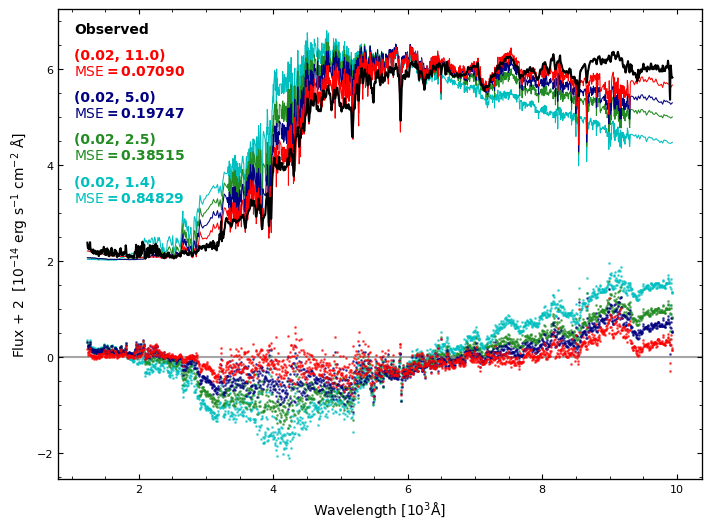

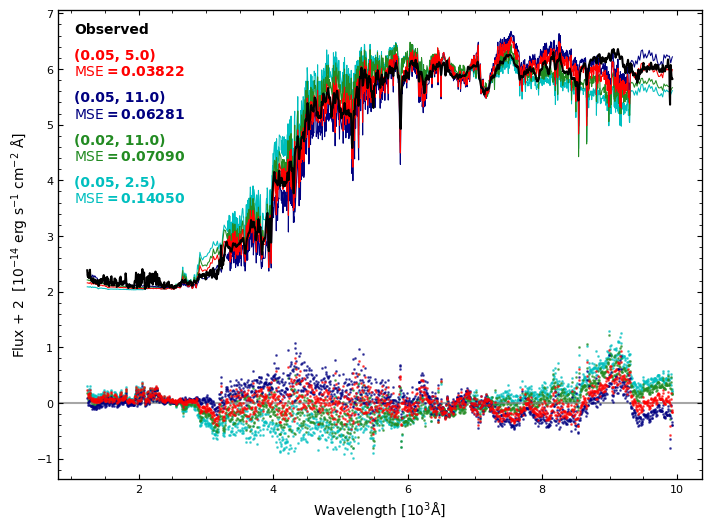

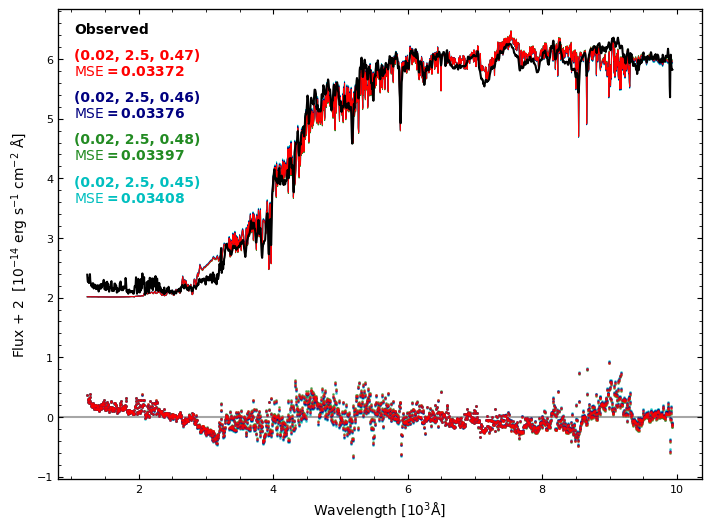

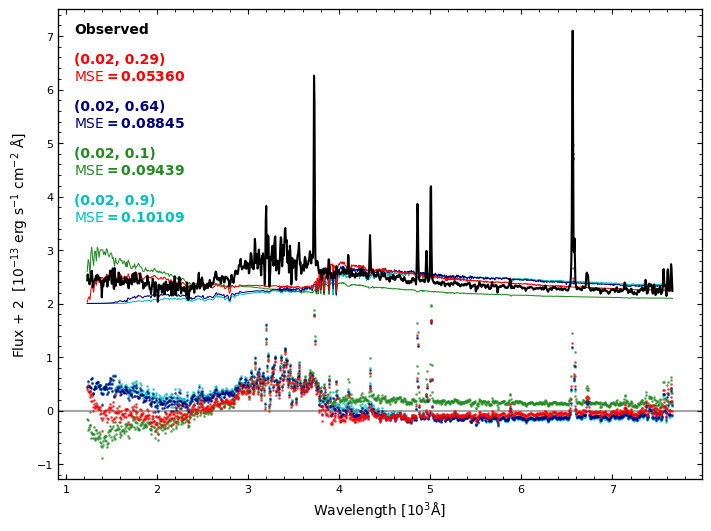

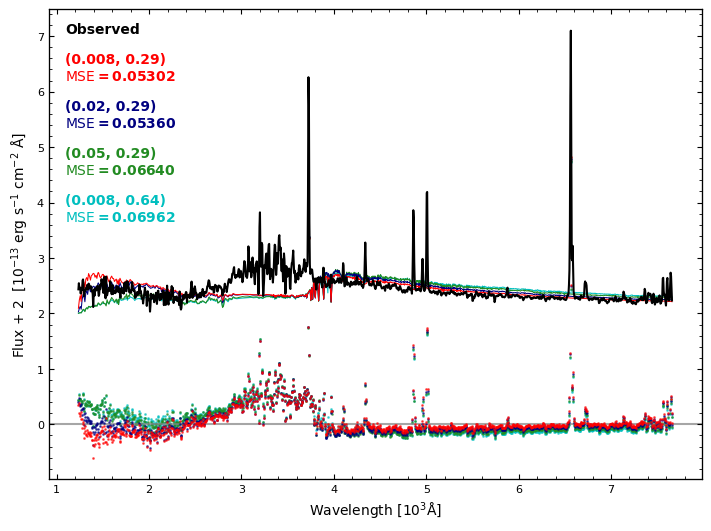

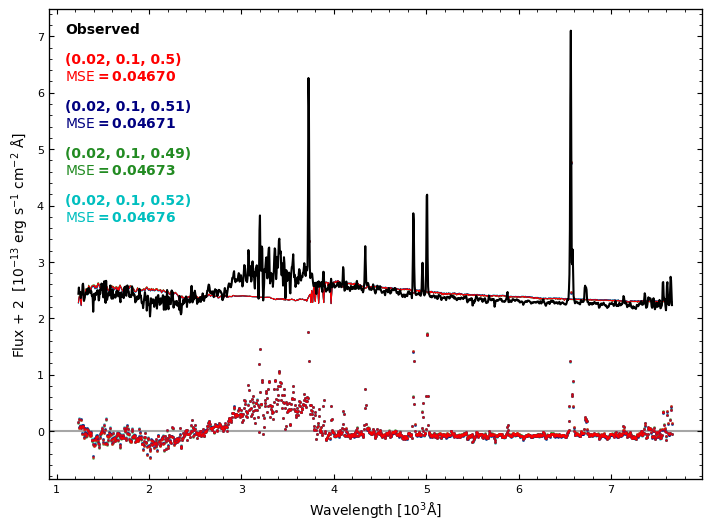

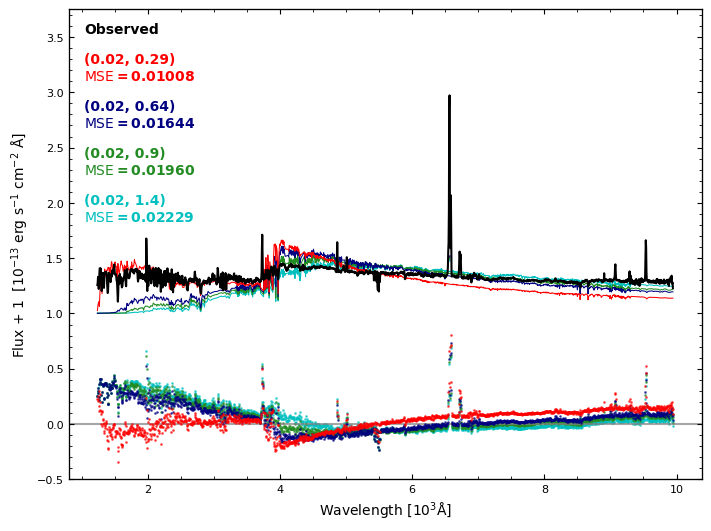

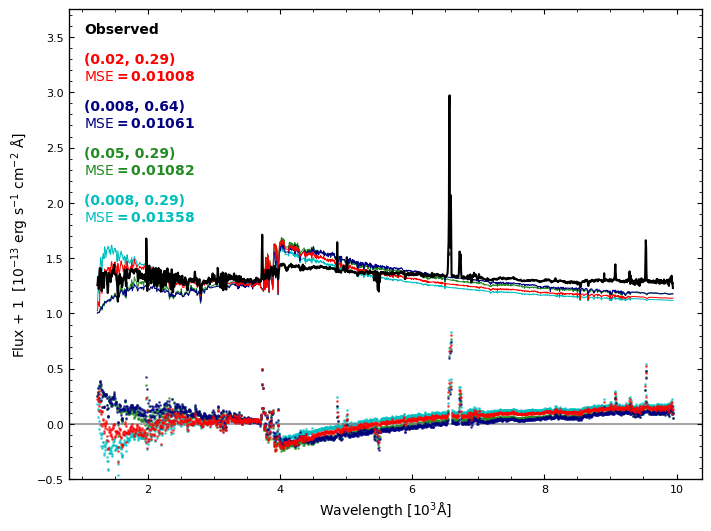

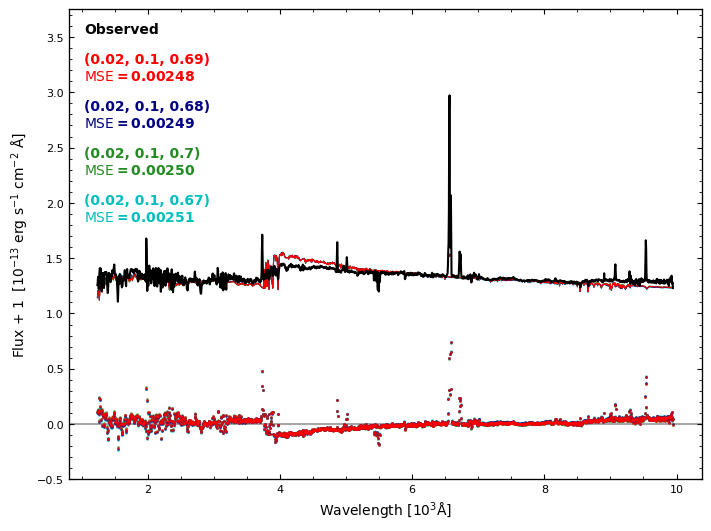

In [2]:
kinney_temp = './kinney_temps/'
elliptical = kinney_temp+"elliptical_template.fits"
sc_gal = kinney_temp+"sc_template.fits"
burst = kinney_temp+"starb6_template.fits"

ssps = get_ssps('./bc03/templates/')

to_mask = np.array([3727, 3869, 4102, 4340, 4861, 4959, 5007, 6300,
    6548, 6563, 6583, 6716, 6731, 5876, 7136])

ell = build_datadict(elliptical, to_mask, 10)
sc = build_datadict(sc_gal, to_mask, 10)
burst = build_datadict(burst, to_mask, 20)

gals = [ell, sc, burst]
flux_norms = [1e-14, 1e-13, 1e-13]

ylabels = ['Flux [$10^{-14} \\ \\mathrm{erg \\ s^{-1} \\ cm^{-2} \\ \\AA}$]',
    'Flux [$10^{-13} \\ \\mathrm{erg \\ s^{-1} \\ cm^{-2} \\ \\AA}$]',
    'Flux [$10^{-13} \\ \\mathrm{erg \\ s^{-1} \\ cm^{-2} \\ \\AA}$]']

titles = ['Elliptical', 'Sc Spiral', 'Starburst']

shifts = [2, 2, 1]

fit_window = (3600, 7000)

text_locs = [(0.025, 0.95), (0.025, 0.95), (0.025, 0.95)]
y_spaces = [0.09, 0.1, 0.1]
x_spaces = [0.185, 0.185, 0.185]
orients = ['vertical', 'vertical', 'vertical']
ylims = [None, None, (-0.5, 3.75)]

for gal, norm, y, t, shift, tloc, yspace, xspace, o, ylim in zip(gals, flux_norms, ylabels, 
    titles, shifts, text_locs, y_spaces, x_spaces, orients, ylims):
    
    gal['solZ_top4'], gal['solZ_ssps'] = find_best_model(ssps,
        gal['raw']['wl'], gal['raw']['flux'],
        key_filter=lambda k: k[0] == 0.02,
        mask=gal['mask'], norm=norm, fit_range=fit_window)

    gal['all_top4'], gal['all_ssps'] = find_best_model(ssps,
        gal['raw']['wl'], gal['raw']['flux'],
        mask=gal['mask'], norm=norm, fit_range=fit_window)
    
    solZ_red = {}
    for key, val in list(gal['solZ_ssps'].items()):
        for eb in np.arange(0, 0.71, 0.01):
            solZ_red[key + (float(f'{eb:.2f}'),)] = redden(val['wl'], val['flux'], eb)

    gal['solZ_red'] = solZ_red
    
    gal['solZ_red_top4'], gal['solZ_red_sort'] = find_best_model(gal['solZ_red'],
        gal['raw']['wl'], gal['raw']['flux'],
        mask=gal['mask'], norm=norm, fit_range=fit_window)

    fig, ax = plot_results(gal['solZ_top4'], 
        gal['raw']['wl'], gal['raw']['flux'],
        wl_norm=1e3, flux_norm=norm,
        ylabel=y, title=t+' (Constant Z)\n', shift=shift,
        text_loc=tloc, text_y_space=yspace, text_x_space=xspace,
        orient=o, ylim=ylim)
    
    fig.savefig(f"./figures/{t.replace(' ', '_')}_solZ")
    
    fig, ax = plot_results(gal['all_top4'], 
        gal['raw']['wl'], gal['raw']['flux'],
        wl_norm=1e3, flux_norm=norm,
        ylabel=y, title=t+'\n', shift=shift,
        text_loc=tloc, text_y_space=yspace, text_x_space=xspace,
        orient=o, ylim=ylim)
    
    fig.savefig(f"./figures/{t.replace(' ', '_')}_all")
    
    fig, ax = plot_results(gal['solZ_red_top4'], 
        gal['raw']['wl'], gal['raw']['flux'],
        wl_norm=1e3, flux_norm=norm,
        ylabel=y, title=t+' (Constant Z, Dust)\n', shift=shift,
        text_loc=tloc, text_y_space=yspace, text_x_space=xspace,
        orient=o, ylim=ylim)
    
    fig.savefig(f"./figures/{t.replace(' ', '_')}_dust")

In [3]:
for gal, title in zip(gals, titles):
    print(f'---------- {title} ----------')
    print(f"Best Solar Metallicity -- (Z, Age [Gyr]): {list(gal['solZ_top4'].keys())[0]}")
    print(f"Best Z/Age Combo -- (Z, Age [Gyr]): {list(gal['all_top4'].keys())[0]}")
    print(f"Best Age/E(B-V) Combo -- (Z, Age [Gyr], E(B-V)): {list(gal['solZ_red_top4'].keys())[0]}\n")

---------- Elliptical ----------
Best Solar Metallicity -- (Z, Age [Gyr]): (0.02, 11.0)
Best Z/Age Combo -- (Z, Age [Gyr]): (0.05, 5.0)
Best Age/E(B-V) Combo -- (Z, Age [Gyr], E(B-V)): (0.02, 2.5, 0.47)

---------- Sc Spiral ----------
Best Solar Metallicity -- (Z, Age [Gyr]): (0.02, 0.29)
Best Z/Age Combo -- (Z, Age [Gyr]): (0.008, 0.29)
Best Age/E(B-V) Combo -- (Z, Age [Gyr], E(B-V)): (0.02, 0.1, 0.5)

---------- Starburst ----------
Best Solar Metallicity -- (Z, Age [Gyr]): (0.02, 0.29)
Best Z/Age Combo -- (Z, Age [Gyr]): (0.02, 0.29)
Best Age/E(B-V) Combo -- (Z, Age [Gyr], E(B-V)): (0.02, 0.1, 0.69)



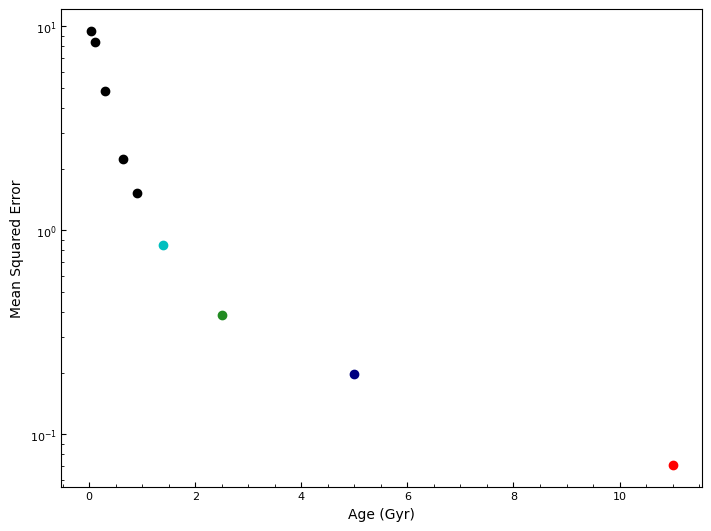

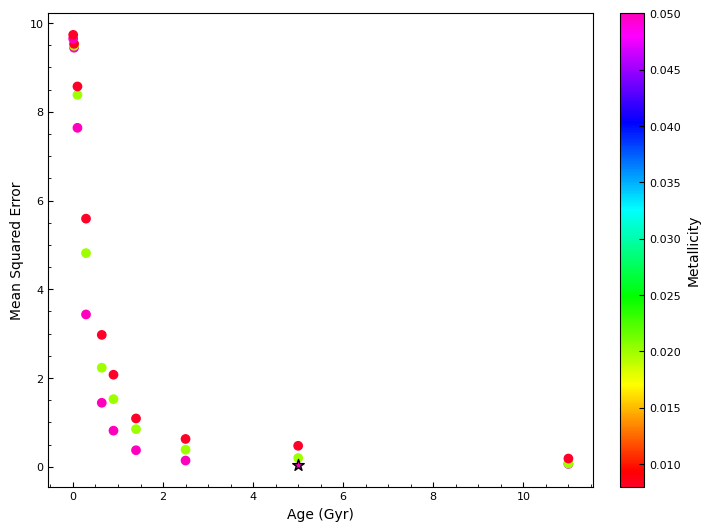

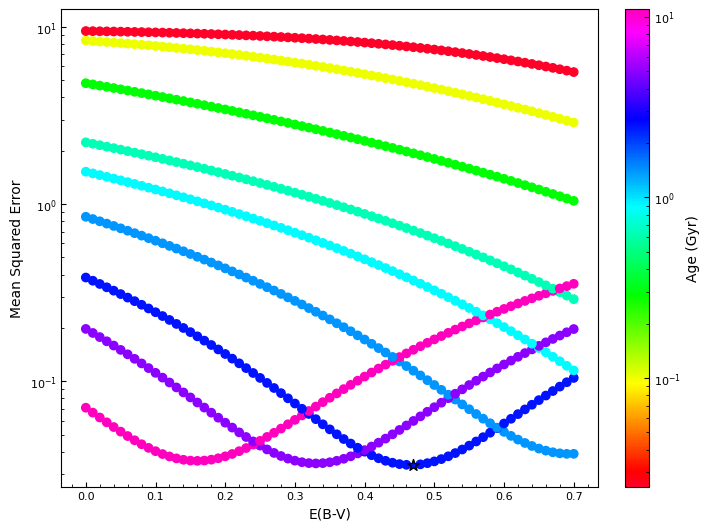

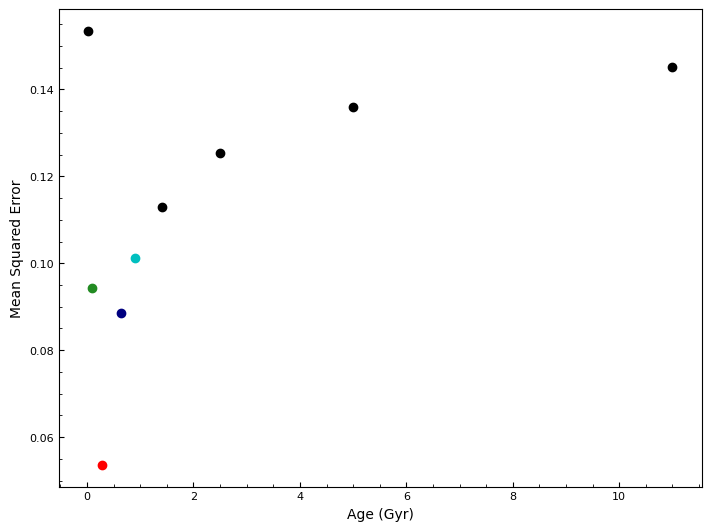

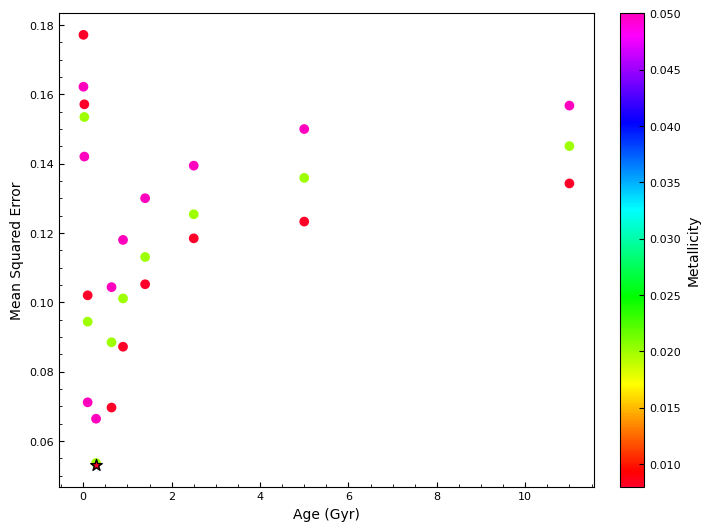

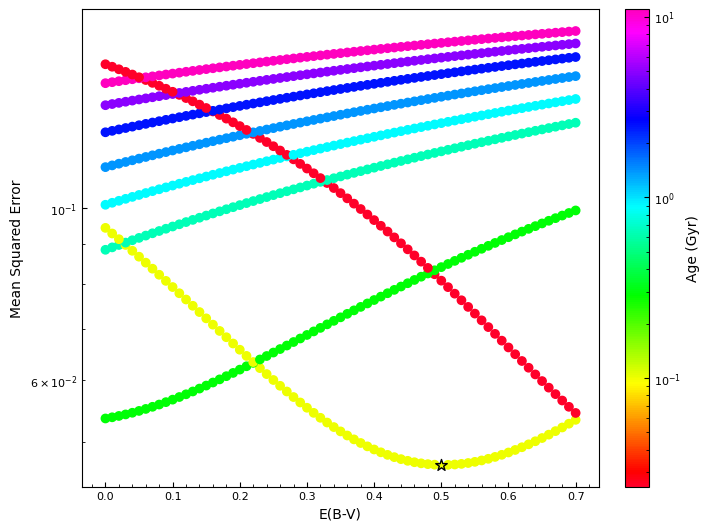

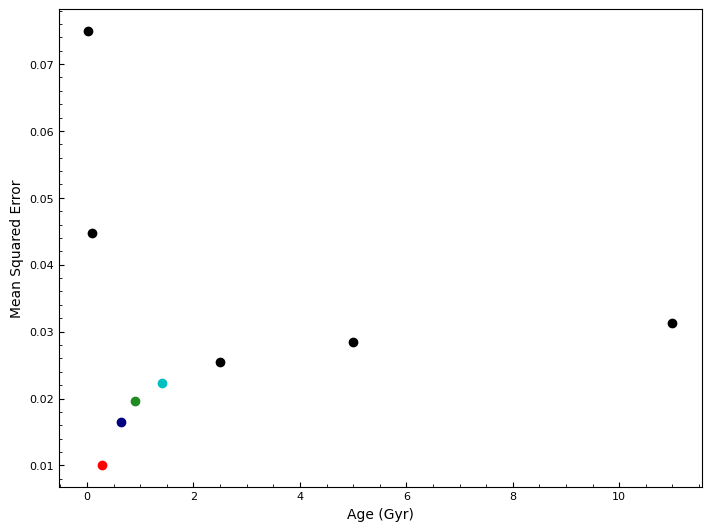

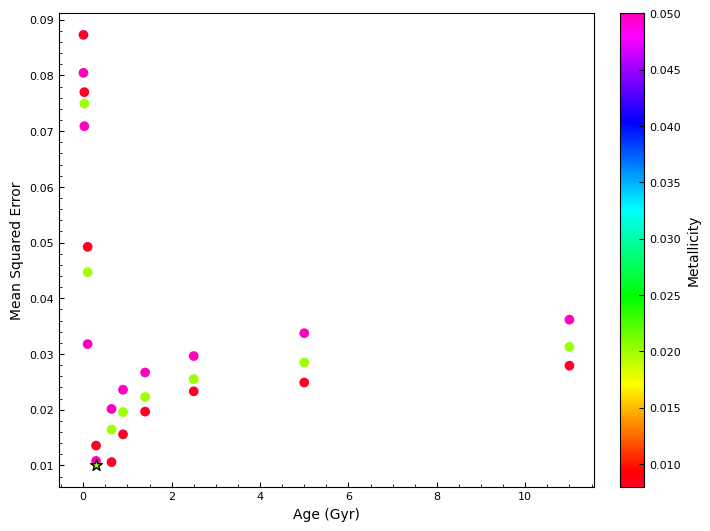

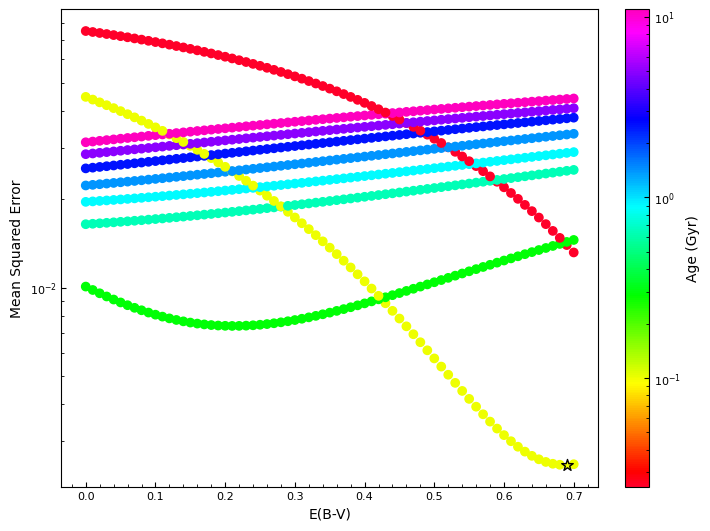

In [4]:
for (idx, gal), t in zip(enumerate(gals), titles):
    
    ages = np.array([i[1] for i in gal['solZ_ssps'].keys()])
    mses = np.array([j['red_chisq'] for j in gal['solZ_ssps'].values()])

    fig, ax = plt.subplots(figsize=(7, 5.2),
                constrained_layout=True)
    ax.scatter(ages[0], mses[0], color=colors[1])
    ax.scatter(ages[1], mses[1], color=colors[2])
    ax.scatter(ages[2], mses[2], color=colors[3])
    ax.scatter(ages[3], mses[3], color=colors[4])
    ax.scatter(ages[4:], mses[4:], zorder=0)
    ax.set_xlabel('Age (Gyr)')
    ax.set_ylabel('Mean Squared Error')
    ax.minorticks_on()
    
    if idx == 0:
        ax.set_yscale('log')
        
    fig.savefig(f'./figures/{t.replace(" ", "_")}_solZ_mse.png')
        
    zs = np.array([i[0] for i in gal['all_ssps'].keys()])
    ages = np.array([i[1] for i in gal['all_ssps'].keys()])
    mses = np.array([j['red_chisq'] for j in gal['all_ssps'].values()])
    
    norm = mcolors.Normalize(vmin=zs.min(), vmax=zs.max())
    cmap = plt.cm.gist_rainbow
    
    fig, ax = plt.subplots(figsize=(7, 5.2),
                constrained_layout=True)
    sc1 = ax.scatter(ages[0], mses[0], c=zs[0], cmap=cmap, 
        norm=norm, marker='*', zorder=1, edgecolors='black', s=75)
    sc = ax.scatter(ages[1:], mses[1:], c=zs[1:], cmap=cmap, norm=norm, zorder=0)
    ax.set_xlabel('Age (Gyr)')
    ax.set_ylabel('Mean Squared Error')
    ax.minorticks_on()
    
    fig.colorbar(sc, ax=ax, label='Metallicity')
    
    fig.savefig(f'./figures/{t.replace(" ", "_")}_all_mse.png')

    ebs = np.array([i[-1] for i in gal['solZ_red_sort'].keys()])
    mses = np.array([j['red_chisq'] for j in gal['solZ_red_sort'].values()])
    ages = np.array([i[1] for i in gal['solZ_red_sort'].keys()])

    log_norm = mcolors.LogNorm(vmin=ages.min(), vmax=ages.max())

    fig, ax = plt.subplots(figsize=(7, 5.2),
                constrained_layout=True)
    sc1 = ax.scatter(ebs[0], mses[0], c=ages[0], cmap=cmap,
        norm=log_norm, marker='*', zorder=1, edgecolors='black', s=75)
    sc = ax.scatter(ebs[1:], mses[1:], c=ages[1:], cmap=cmap, norm=log_norm, zorder=0)
    ax.set_xlabel('E(B-V)')
    ax.set_ylabel('Mean Squared Error')
    ax.set_yscale('log')
    ax.minorticks_on()

    fig.colorbar(sc, ax=ax, label='Age (Gyr)')
    
    fig.savefig(f'./figures/{t.replace(" ", "_")}_red_mse.png')